# Load processed data

In [3]:
from pathlib import Path
import pandas as pd
import geopandas as gpd

PROCESSED_PATH = Path("./processed_data")

print("Files in processed_data:")
for file in sorted(PROCESSED_PATH.iterdir()):
    print(file.name)
 
# Load dataset
# Bus usage datasets

bus_avg = pd.read_csv(
    PROCESSED_PATH / "bus_avg.csv",
    parse_dates=["Date"]
)

bus_avg_grouped = pd.read_csv(
    PROCESSED_PATH / "bus_avg_grouped.csv",
    parse_dates=["Date"]
)

bus_monthly = pd.read_csv(
    PROCESSED_PATH / "bus_monthly.csv",
    parse_dates=["Date"]
)

# Bike lane intervention data

bike_lanes = gpd.read_file(
    PROCESSED_PATH / "bike_lanes.geojson"
)

# Spatial bus datasets

bus_lines = gpd.read_file(
    PROCESSED_PATH / "bus_lines.geojson"
)

bus_stops_geo = gpd.read_file(
    PROCESSED_PATH / "bus_stops.geojson"
)

# GTFS route-level data

bus_routes = pd.read_csv(
    PROCESSED_PATH / "bus_routes.csv"
)

bus_trips = pd.read_csv(
    PROCESSED_PATH / "bus_trips.csv"
)

bus_shapes = pd.read_csv(
    PROCESSED_PATH / "bus_shapes.csv"
)

bus_stops = pd.read_csv(
    PROCESSED_PATH / "bus_stops.csv"
) 

Files in processed_data:
bike_lanes.geojson
bus_avg.csv
bus_avg_grouped.csv
bus_lines.geojson
bus_monthly.csv
bus_routes.csv
bus_shapes.csv
bus_stop_times.csv
bus_stops.csv
bus_stops.geojson
bus_trips.csv


## Setup daterange from each dataset

In [4]:
print("Bus monthly period:")
print(bus_monthly["Date"].min())
print(bus_monthly["Date"].max())

print("\nBus average period:")
print(bus_avg_grouped["Date"].min())
print(bus_avg_grouped["Date"].max())

print("\nBike lane trial start:")
print(bike_lanes["trial_start"].min())
print(bike_lanes["trial_start"].max())

print("\nBike lane trial end:")
print(bike_lanes["trial_end"].min())
print(bike_lanes["trial_end"].max())

Bus monthly period:
2018-01-01 00:00:00
2026-03-01 00:00:00

Bus average period:
2018-01-01 00:00:00
2026-03-01 00:00:00

Bike lane trial start:
0001-02-22 00:00:00
0001-07-22 00:00:00

Bike lane trial end:
0001-07-23 00:00:00
0001-10-23 00:00:00


In [6]:
bike_lanes["trial_start"] = pd.to_datetime(
    bike_lanes["trial_start"],
    errors="coerce"
)

bike_lanes["trial_end"] = pd.to_datetime(
    bike_lanes["trial_end"],
    errors="coerce"
)

print(bike_lanes[
    ["intervention_id", "road_name", "trial_start", "trial_end"]
].head(10))

# 
completed = bike_lanes["trial_end"].notna()

print("Total interventions:", len(bike_lanes))
print("With start date:", bike_lanes["trial_start"].notna().sum())
print("With end date:", bike_lanes["trial_end"].notna().sum())
print("Without end date:", bike_lanes["trial_end"].isna().sum())

   intervention_id           road_name trial_start trial_end
0                2      Charles Street     1-07-22       NaT
1                3       Albert Street     1-07-22       NaT
2                4       Albert Street     1-07-22       NaT
3                5      Mitford Street     1-07-22   1-07-23
4                6        Beach Avenue     1-07-22   1-07-23
5                7  Blessington Street     1-07-22   1-07-23
6                8       Marine Parade     1-07-22       NaT
7                9      William Street     1-07-22   1-07-23
8               10    Myrnong Crescent     1-07-22       NaT
9               11        McNae Street     1-07-22       NaT
Total interventions: 354
With start date: 349
With end date: 121
Without end date: 233


# What types of bike lanes were installed?

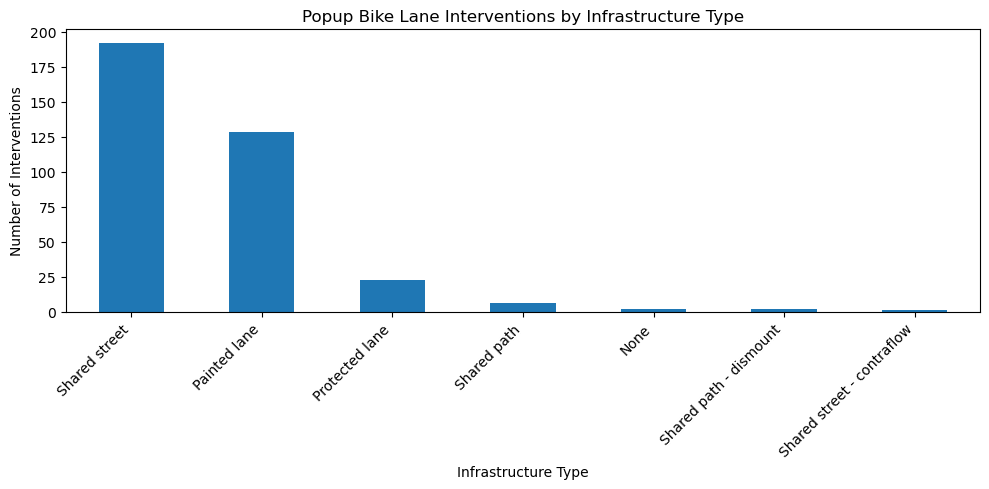

In [9]:
from matplotlib import pyplot as plt
bike_lanes["trial_infrastructure"].value_counts()

bike_lanes["trial_infrastructure"].value_counts().plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Popup Bike Lane Interventions by Infrastructure Type")
plt.xlabel("Infrastructure Type")
plt.ylabel("Number of Interventions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Interventions by Local Government Area (LGA)

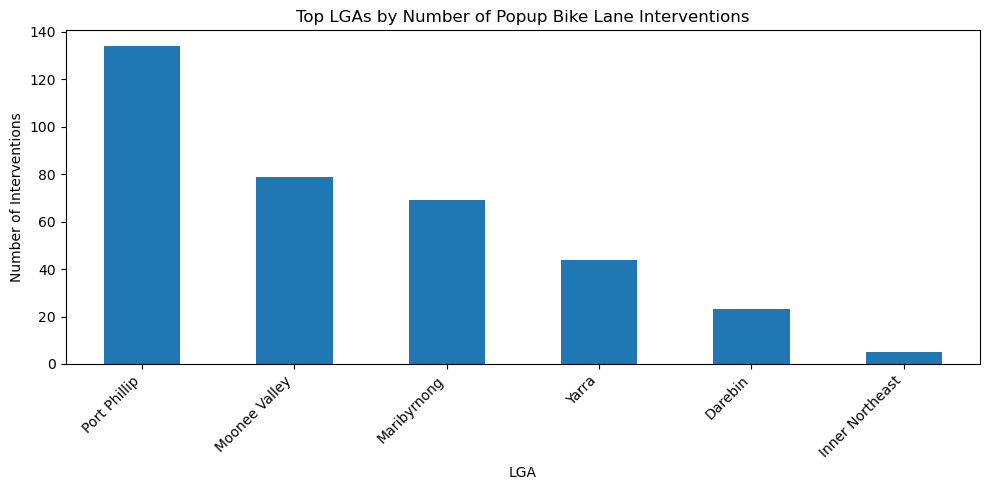

In [11]:
lga_counts = (
    bike_lanes["lga"]
    .value_counts()
    .sort_values(ascending=False)
)

lga_counts.head(15)

lga_counts.head(1300).plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Top LGAs by Number of Popup Bike Lane Interventions")
plt.xlabel("LGA")
plt.ylabel("Number of Interventions")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# When did the interventiosn duration?

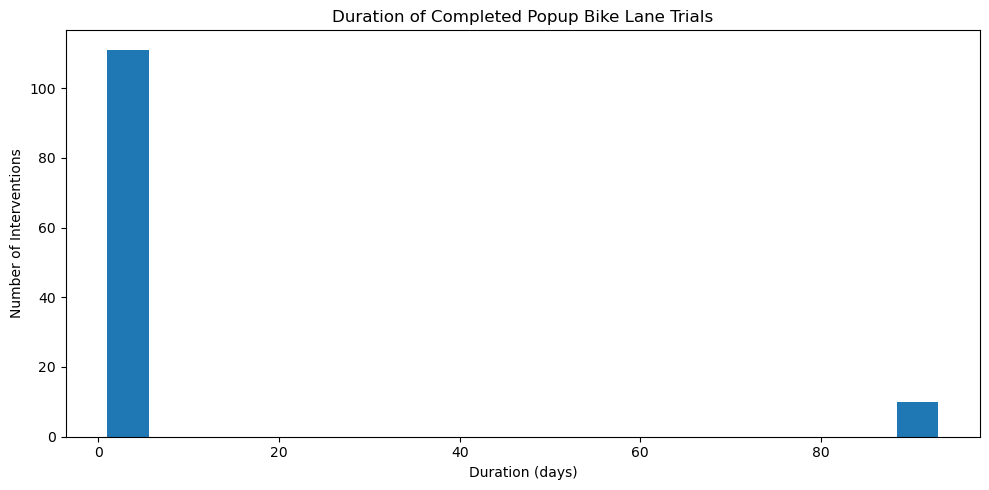

In [13]:
completed_bike_lanes = bike_lanes[
    bike_lanes["trial_end"].notna()
].copy()

completed_bike_lanes["duration_days"] = (
    completed_bike_lanes["trial_end"]
    - completed_bike_lanes["trial_start"]
).dt.days
completed_bike_lanes["duration_days"].describe()

completed_bike_lanes["duration_days"].plot(
    kind="hist",
    bins=20,
    figsize=(10, 5)
)

plt.title("Duration of Completed Popup Bike Lane Trials")
plt.xlabel("Duration (days)")
plt.ylabel("Number of Interventions")
plt.tight_layout()
plt.show()

# Bus Usage

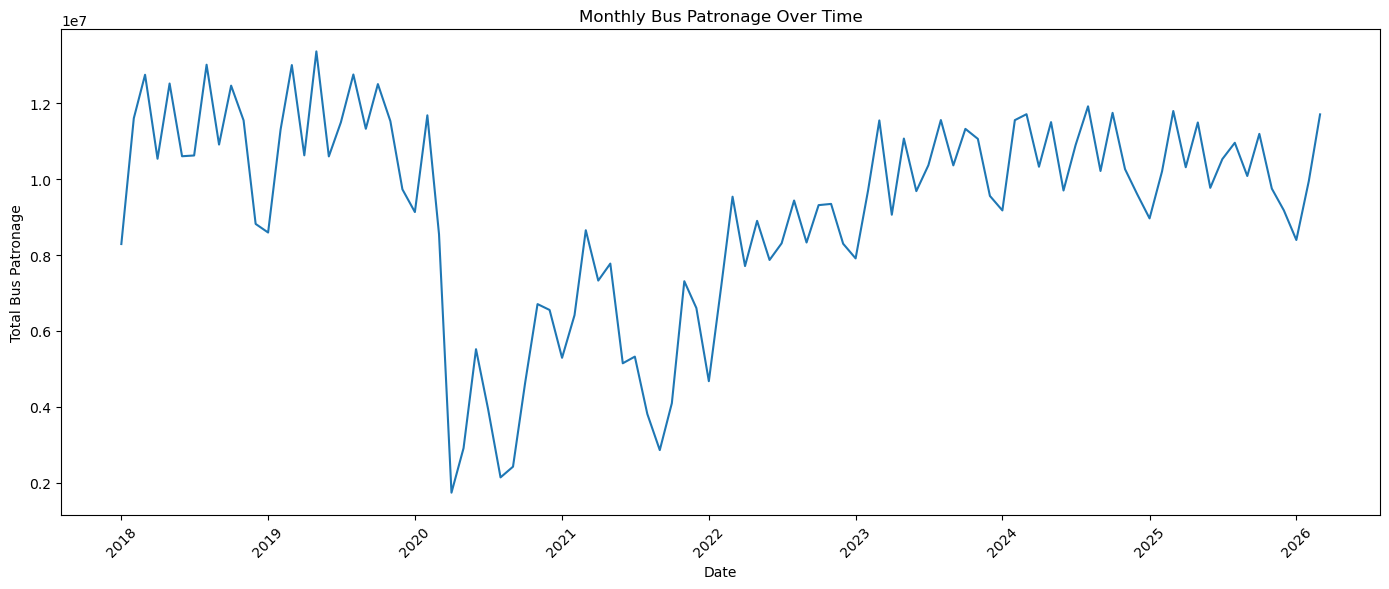

In [14]:
bus_monthly.describe()

plt.figure(figsize=(14, 6))

plt.plot(
    bus_monthly["Date"],
    bus_monthly["Total_bus"]
)

plt.title("Monthly Bus Patronage Over Time")
plt.xlabel("Date")
plt.ylabel("Total Bus Patronage")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# MetroBus vs REgionalBUs

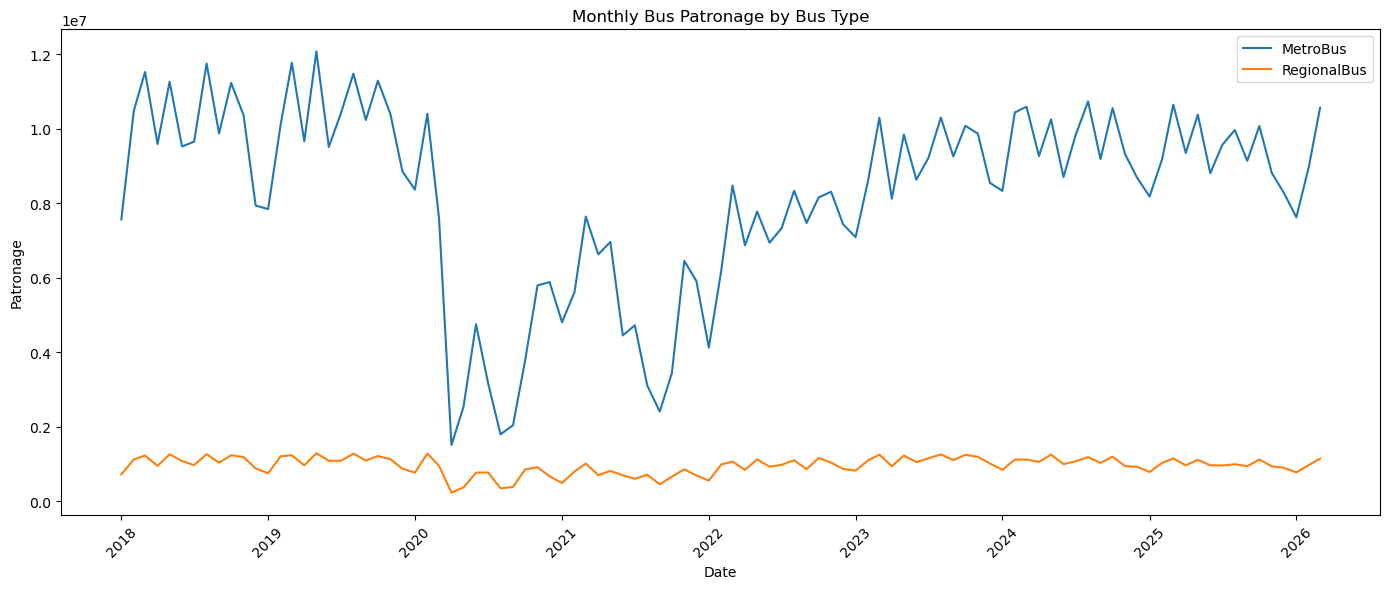

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(
    bus_monthly["Date"],
    bus_monthly["Metropolitan bus"],
    label="MetroBus"
)

plt.plot(
    bus_monthly["Date"],
    bus_monthly["Regional bus"],
    label="RegionalBus"
)

plt.title("Monthly Bus Patronage by Bus Type")
plt.xlabel("Date")
plt.ylabel("Patronage")
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Month-to-Month bus percentage change

In [17]:
bus_monthly["MetroBus_pct_change"] = (
    bus_monthly["Metropolitan bus"]
    .pct_change() * 100
)

bus_monthly["RegionalBus_pct_change"] = (
    bus_monthly["Regional bus"]
    .pct_change() * 100
)

bus_monthly["TotalBus_pct_change"] = (
    bus_monthly["Total_bus"]
    .pct_change() * 100
)
bus_monthly[
    [
        "Date",
        "Metropolitan bus",
        "MetroBus_pct_change",
        "TotalBus_pct_change"
    ]
].head(15)

,Date,Metropolitan bus,MetroBus_pct_change,TotalBus_pct_change
0,2018-01-01,7568547,NaN,NaN
1,2018-02-01,10487311,38.564390,40.001431
2,2018-03-01,11528895,9.931850,9.890792
3,2018-04-01,9592750,-16.793847,-17.365479
4,2018-05-01,11263486,17.416653,18.817991
5,2018-06-01,9526795,-15.418770,-15.312218
6,2018-07-01,9657327,1.370156,0.190330
7,2018-08-01,11756706,21.738717,22.523176
8,2018-09-01,9878596,-15.974798,-16.175042
9,2018-10-01,11233979,13.720401,14.241134


# Pop up bike lanter interventions on the bus timeline

In [18]:
intervention_monthly = (
    bike_lanes
    .dropna(subset=["trial_start"])
    .assign(
        intervention_month=lambda x:
        x["trial_start"].dt.to_period("M").dt.to_timestamp()
    )
    .groupby("intervention_month")
    .size()
    .reset_index(name="intervention_count")
)

bus_intervention_timeline = bus_monthly.merge(
    intervention_monthly,
    left_on="Date",
    right_on="intervention_month",
    how="left"
)

bus_intervention_timeline["intervention_count"] = (
    bus_intervention_timeline["intervention_count"]
    .fillna(0)
)

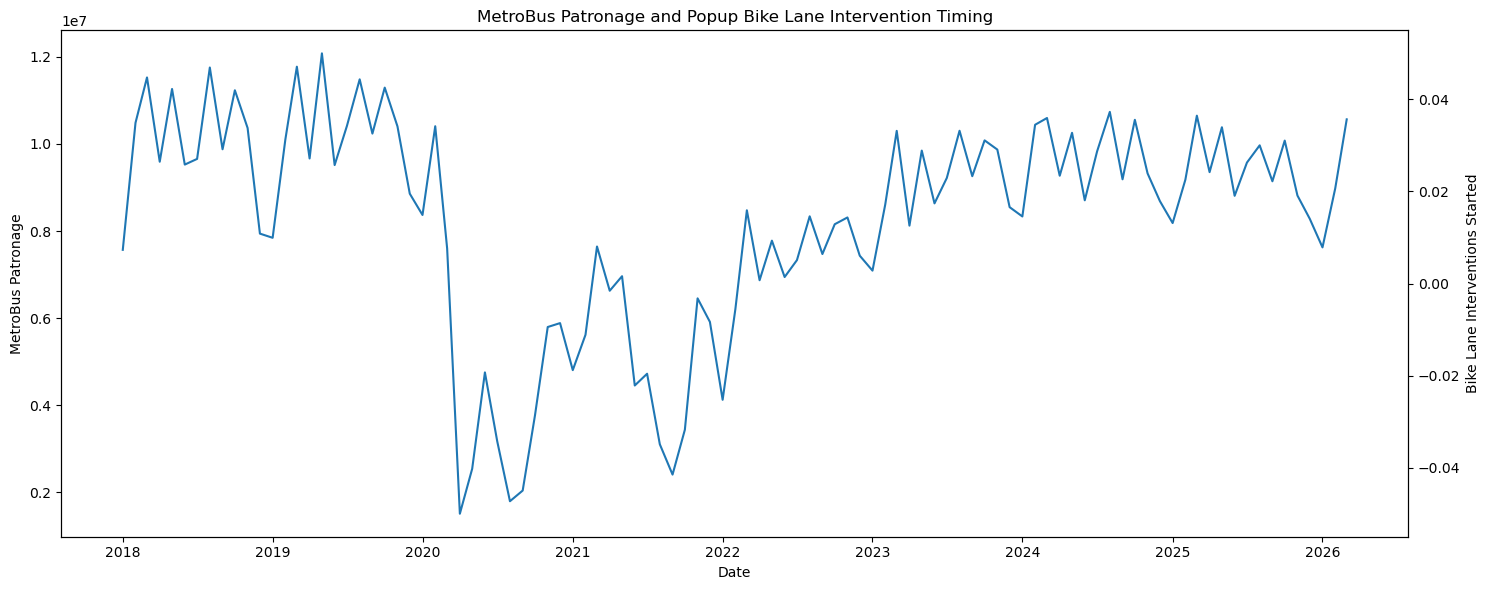

In [ ]:
# Visualize Bike lane interventions aginst bus usage
fig, ax1 = plt.subplots(figsize=(15, 6))

ax1.plot(
    bus_intervention_timeline["Date"],
    bus_intervention_timeline["Metropolitan bus"]
)
ax1.set_xlabel("Date")
ax1.set_ylabel("MetroBus Patronage")

ax2 = ax1.twinx()
ax2.bar(
    bus_intervention_timeline["Date"],
    bus_intervention_timeline["intervention_count"],
    alpha=0.3
)
ax2.set_ylabel("Bike Lane Interventions Started")

plt.title(
    "MetroBus Patronage and Popup Bike Lane Intervention Timing"
)

plt.tight_layout()
plt.show()